In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv ("processed_hungarian.csv", header=None)

In [5]:
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,28,1,2,130,132,0,2,185,0,0.0,?,?,?,0
1,29,1,2,120,243,0,0,160,0,0.0,?,?,?,0
2,29,1,2,140,?,0,0,170,0,0.0,?,?,?,0
3,30,,1,170,237,0,1,170,0,0.0,?,?,6,0
4,31,0,2,100,219,0,1,150,0,0.0,?,?,?,0


In [6]:
# Buat nama kolom
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'
]

# Masukkan ke df
df.columns = column_names

In [7]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,28,1,2,130,132,0,2,185,0,0.0,?,?,?,0
1,29,1,2,120,243,0,0,160,0,0.0,?,?,?,0
2,29,1,2,140,?,0,0,170,0,0.0,?,?,?,0
3,30,,1,170,237,0,1,170,0,0.0,?,?,6,0
4,31,0,2,100,219,0,1,150,0,0.0,?,?,?,0


In [8]:
df.replace('?', np.nan, inplace=True)

In [9]:
df.isnull().sum()

age           0
sex           1
cp            0
trestbps      1
chol         23
fbs           8
restecg       1
thalach       1
exang         1
oldpeak       0
slope       190
ca          291
thal        266
num           0
dtype: int64

cek tipe data

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       294 non-null    int64  
 1   sex       293 non-null    object 
 2   cp        294 non-null    int64  
 3   trestbps  293 non-null    object 
 4   chol      271 non-null    object 
 5   fbs       286 non-null    object 
 6   restecg   293 non-null    object 
 7   thalach   293 non-null    object 
 8   exang     293 non-null    object 
 9   oldpeak   294 non-null    float64
 10  slope     104 non-null    object 
 11  ca        3 non-null      object 
 12  thal      28 non-null     object 
 13  num       294 non-null    int64  
dtypes: float64(1), int64(3), object(10)
memory usage: 32.3+ KB


ubah tipe data

In [11]:
tipe_data_baru = {
    'sex': 'category',
    'cp': 'category', 
    'trestbps': 'float64',
    'chol': 'float64',
    'fbs': 'category',
    'restecg': 'category',
    'thalach': 'float64',
    'exang': 'category',
    'slope': 'category',
    'ca': 'float64', 
    'thal': 'category'
}

In [12]:
df = df.astype(tipe_data_baru)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       294 non-null    int64   
 1   sex       293 non-null    category
 2   cp        294 non-null    category
 3   trestbps  293 non-null    float64 
 4   chol      271 non-null    float64 
 5   fbs       286 non-null    category
 6   restecg   293 non-null    category
 7   thalach   293 non-null    float64 
 8   exang     293 non-null    category
 9   oldpeak   294 non-null    float64 
 10  slope     104 non-null    category
 11  ca        3 non-null      float64 
 12  thal      28 non-null     category
 13  num       294 non-null    int64   
dtypes: category(7), float64(5), int64(2)
memory usage: 19.2 KB


In [14]:
df.nunique()

age          39
sex           4
cp            4
trestbps     31
chol        153
fbs           2
restecg       3
thalach      71
exang         2
oldpeak      10
slope         3
ca            1
thal          3
num           2
dtype: int64

In [15]:
# Daftar nilai yang dianggap valid
valid_sex_values = [0, 1]

# Fungsi
invalid_sex_rows = df[~df['sex'].isin(valid_sex_values)]

In [16]:
invalid_sex_rows

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,28,1,2,130.0,132.0,0,2,185.0,0,0.0,NaN,NaN,NaN,0
1,29,1,2,120.0,243.0,0,0,160.0,0,0.0,NaN,NaN,NaN,0
2,29,1,2,140.0,NaN,0,0,170.0,0,0.0,NaN,NaN,NaN,0
3,30,,1,170.0,237.0,0,1,170.0,0,0.0,NaN,NaN,6,0
4,31,0,2,100.0,219.0,0,1,150.0,0,0.0,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
289,52,1,4,160.0,331.0,0,0,94.0,1,2.5,NaN,NaN,NaN,1
290,54,0,3,130.0,294.0,0,1,100.0,1,0.0,2,NaN,NaN,1
291,56,1,4,155.0,342.0,1,0,150.0,1,3.0,2,NaN,NaN,1
292,58,0,2,180.0,393.0,0,0,110.0,1,1.0,2,NaN,7,1


In [17]:
df['sex'].replace(999, np.nan, inplace=True)

/var/folders/gs/b23h8b0d4h73h3gp616lr10c0000gn/T/ipykernel_2696/3383421395.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['sex'].replace(999, np.nan, inplace=True)


In [18]:
df.isnull().sum()

age           0
sex           1
cp            0
trestbps      1
chol         23
fbs           8
restecg       1
thalach       1
exang         1
oldpeak       0
slope       190
ca          291
thal        266
num           0
dtype: int64

In [19]:
# Hitung jumlah missing value
missing = df.isnull().sum()

# Hitung persentase missing value
percent = (missing / len(df)) * 100

# Gabungkan jadi satu tabel
missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percent (%)': percent.round(2)
})

print(missing_df)

          Missing Values  Percent (%)
age                    0         0.00
sex                    1         0.34
cp                     0         0.00
trestbps               1         0.34
chol                  23         7.82
fbs                    8         2.72
restecg                1         0.34
thalach                1         0.34
exang                  1         0.34
oldpeak                0         0.00
slope                190        64.63
ca                   291        98.98
thal                 266        90.48
num                    0         0.00


In [20]:
df.shape

(294, 14)

In [21]:
df.describe()

,age,trestbps,chol,thalach,oldpeak,ca,num
count,294.000000,293.000000,271.000000,293.000000,294.000000,3.0,294.000000
mean,47.030612,132.583618,250.848708,139.129693,0.586054,0.0,0.360544
std,9.958399,17.626568,67.657711,23.589749,0.908648,0.0,0.480977
min,0.000000,92.000000,85.000000,82.000000,0.000000,0.0,0.000000
25%,41.250000,120.000000,209.000000,122.000000,0.000000,0.0,0.000000
50%,48.000000,130.000000,243.000000,140.000000,0.000000,0.0,0.000000
75%,54.000000,140.000000,282.500000,155.000000,1.000000,0.0,1.000000
max,66.000000,200.000000,603.000000,190.000000,5.000000,0.0,1.000000


In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
kolom_numerik = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

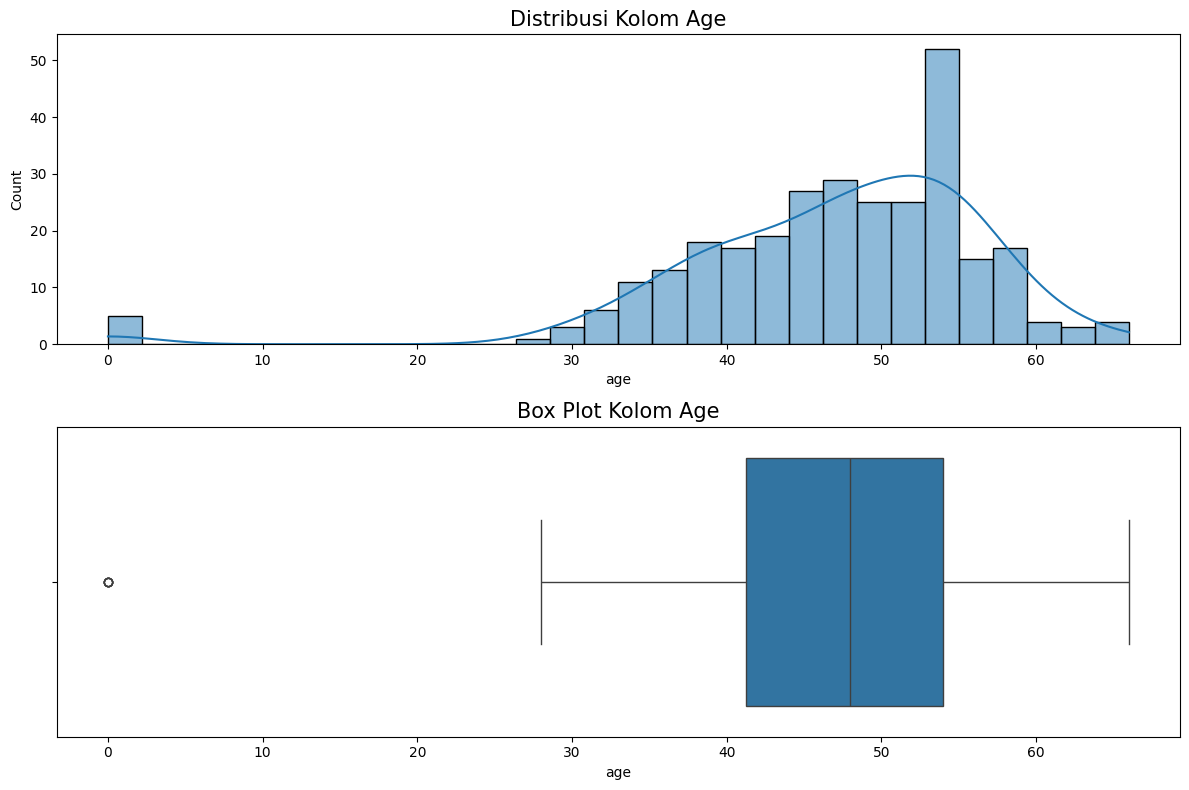

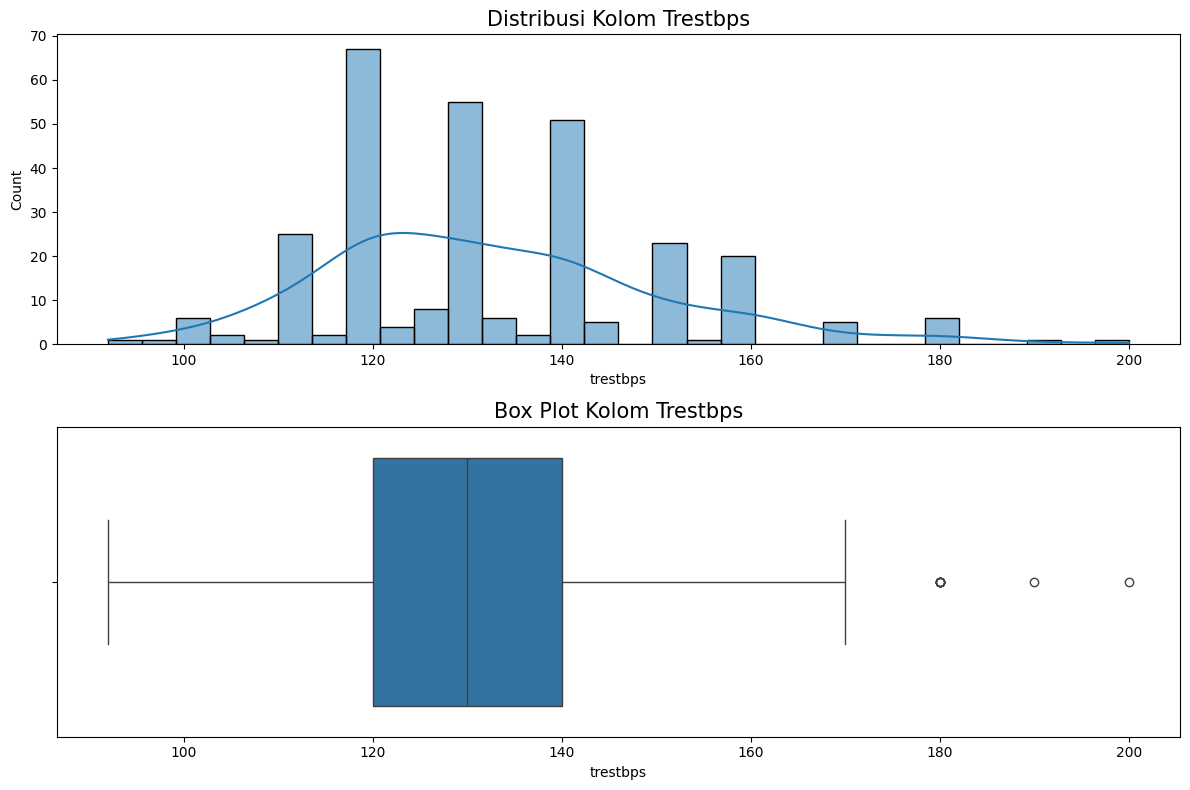

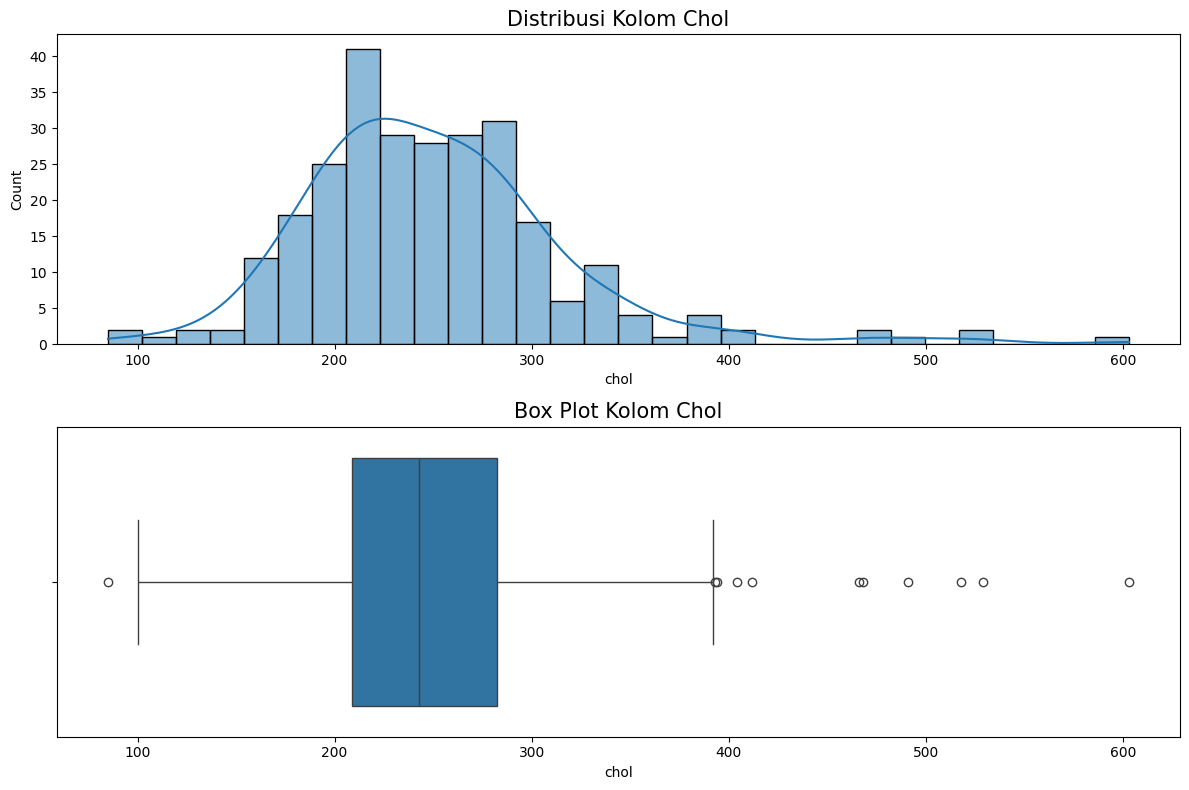

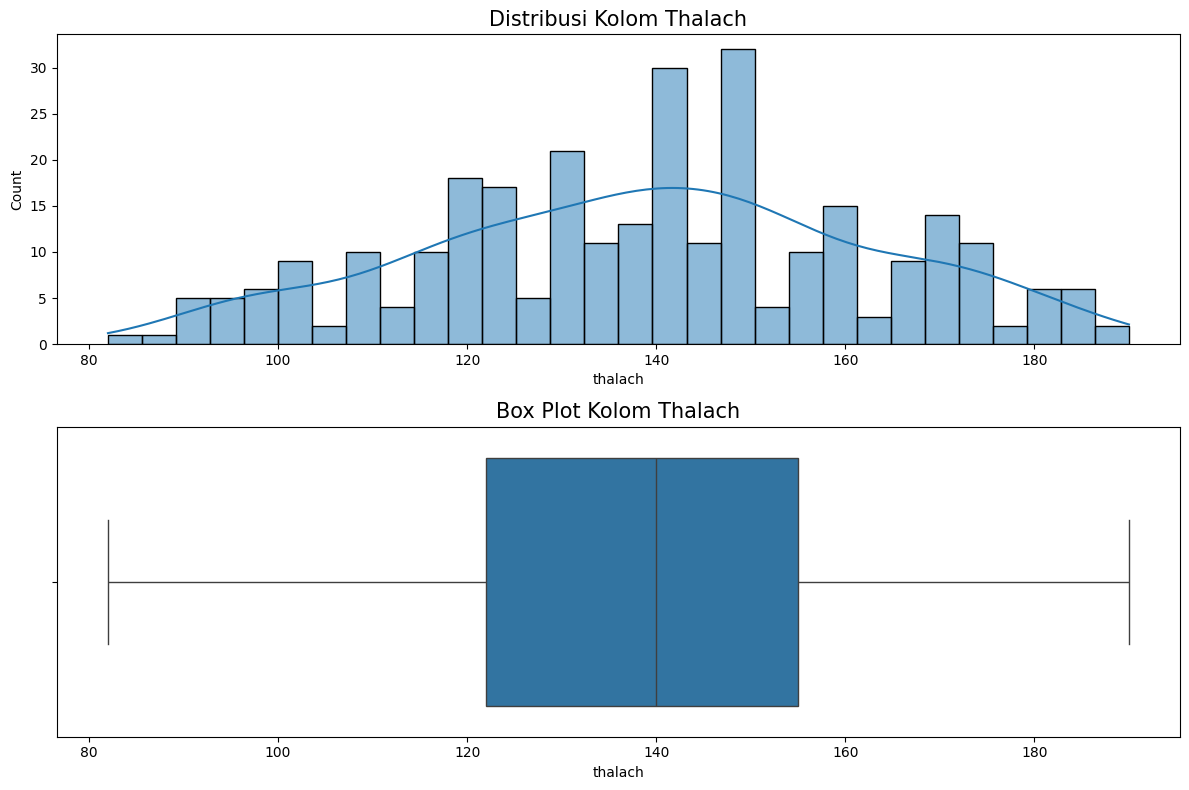

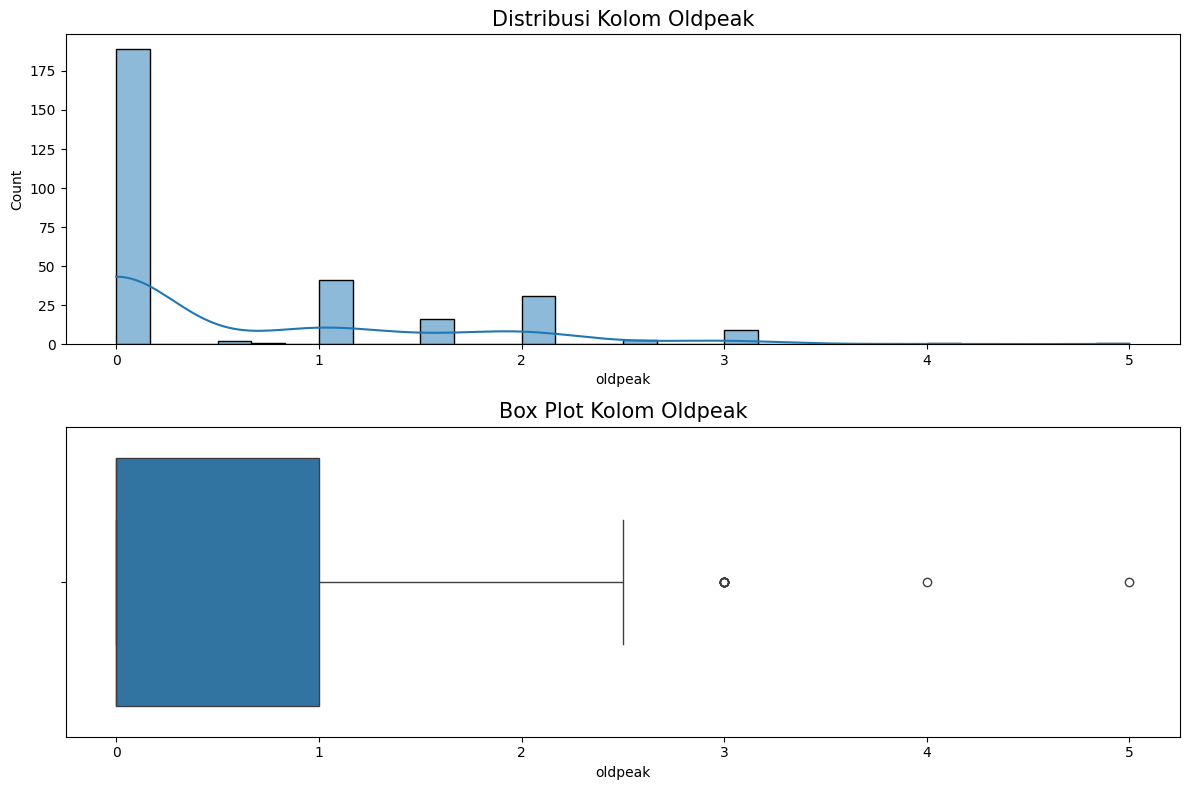

In [24]:
for kolom in kolom_numerik:
    # Atur ukuran plot
    plt.figure(figsize=(12, 8))
    
    # Buat subplot pertama untuk Distribution Plot
    plt.subplot(2, 1, 1)
    sns.histplot(df[kolom], kde=True, bins=30)
    plt.title(f'Distribusi Kolom {kolom.capitalize()}', fontsize=15)
    
    # Buat subplot kedua untuk Box Plot
    plt.subplot(2, 1, 2)
    sns.boxplot(x=df[kolom])
    plt.title(f'Box Plot Kolom {kolom.capitalize()}', fontsize=15)
    
    # Rapikan layout dan tampilkan plot
    plt.tight_layout()
    plt.show()

In [26]:
# Coba Imputasi dengan KNN / Iterative Imputer